# Model Training for Anomaly Detection

**Pipeline:** Isolation Forest (global anomalies) and Local Outlier Factor (local anomalies) on the Spanish tourist accommodation market.

**Scope of this notebook:** train and configure both models, run a sensitivity analysis of their hyperparameters and save the resulting scores/flags/config.


## 0. Imports and configuration

In [73]:
import sys
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
plt.style.use("default")

RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs")
MODELS_DIR = Path("models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Dataset loading and verification

Load the dataset already prepared for modeling and check its integrity (shape,
absence of `NaN`/`inf`) before doing anything else.


In [74]:
df = pd.read_csv("data/dataset_anomaly_detection_ready.csv")

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows:    111,744
Columns: 55


,id,room_id,name,log_price,log_sqm,num_rooms,num_bathrooms,price_per_sqm,sqm_per_room,baths_per_room,discount_pct,price_relative_to_type,price_relative_to_province,pool_flag,beach_flag,breakfast,cancellation,property_type_Agroturismo,property_type_Albergue,property_type_Apartahotel,property_type_Apartamento,property_type_Barco,property_type_Bed and breakfast,property_type_Camping,property_type_Camping resort,property_type_Casa o chalet,property_type_Casa rural,property_type_Chalet de montaña,property_type_Habitación en casa particular,property_type_Hostal o pensión,property_type_Hotel,property_type_Lodge,property_type_Love hotel,property_type_Posada u hostería,property_type_Resort,property_type_Villa,region_Andalucía,region_Aragón,region_Canary Islands,region_Cantabria,region_Castilla y León,region_Castilla-La Mancha,region_Cataluña,region_Ceuta,region_Comunidad Foral de Navarra,region_Comunidad Valenciana,region_Comunidad de Madrid,region_Extremadura,region_Galicia,region_Islas Baleares,region_La Rioja,region_Melilla,region_País Vasco,region_Principado de Asturias,region_Región de Murcia
0,10001060,1000106001,Apartamento Ría Villaviciosa,-0.222086,0.000000,0.0,1.0,-0.205477,-0.258398,0.666667,0.970551,-0.127433,-0.157990,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,10001085,1000108501,Vive tu vida soñada delante del mar,-0.149174,1.328569,0.0,0.0,-0.883150,2.454780,-0.333333,0.000000,-0.053388,-0.230863,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000112,100011202,La Vista de Medina By La Vista Medina Stays,-0.496882,-1.470205,-0.5,0.0,1.312561,-0.775194,0.666667,0.000000,-0.373965,-0.240674,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1000115,100011501,Hostal Catalina de Austria,-1.301552,-0.484204,-1.0,-1.0,-0.625775,0.516796,-1.333333,0.000000,-0.492921,-0.815644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1000144,100014401,Casa Candela,1.382978,2.113920,0.0,1.0,-0.505518,5.684755,0.666667,0.000000,1.634356,2.723777,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [75]:
nan_counts = df.isna().sum()
n_nan_total = nan_counts.sum()
print(f"Total NaN values: {n_nan_total}")
if n_nan_total > 0:
    display(nan_counts[nan_counts > 0].to_frame("n_nan"))

numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
n_inf_total = inf_counts.sum()
print(f"Total inf/-inf values: {n_inf_total}")
if n_inf_total > 0:
    display(inf_counts[inf_counts > 0].to_frame("n_inf"))

assert n_nan_total == 0, "The dataset contains NaN values: review preprocessing before modeling."
assert n_inf_total == 0, "The dataset contains infinite values: review preprocessing before modeling."


Total NaN values: 0
Total inf/-inf values: 0


In [76]:
id_cols = ['id', 'room_id', 'name']
missing_ids = [c for c in id_cols if c not in df.columns]
assert not missing_ids, f"Missing identifier columns: {missing_ids}"

ids_df = df[id_cols].copy()
feature_cols = [c for c in df.columns if c not in id_cols]

assert not (set(id_cols) & set(feature_cols)), "Identifiers must not be part of the modeling variables."

print(f"Identifiers separated: {id_cols}")
print(f"Number of candidate modeling variables: {len(feature_cols)}")


Identifiers separated: ['id', 'room_id', 'name']
Number of candidate modeling variables: 52


In [77]:
print("Variables that enter the models (X):\n")
for i, c in enumerate(feature_cols, 1):
    print(f"{i:>2}. {c}")


Variables that enter the models (X):

 1. log_price
 2. log_sqm
 3. num_rooms
 4. num_bathrooms
 5. price_per_sqm
 6. sqm_per_room
 7. baths_per_room
 8. discount_pct
 9. price_relative_to_type
10. price_relative_to_province
11. pool_flag
12. beach_flag
13. breakfast
14. cancellation
15. property_type_Agroturismo
16. property_type_Albergue
17. property_type_Apartahotel
18. property_type_Apartamento
19. property_type_Barco
20. property_type_Bed and breakfast
21. property_type_Camping
22. property_type_Camping resort
23. property_type_Casa o chalet
24. property_type_Casa rural
25. property_type_Chalet de montaña
26. property_type_Habitación en casa particular
27. property_type_Hostal o pensión
28. property_type_Hotel
29. property_type_Lodge
30. property_type_Love hotel
31. property_type_Posada u hostería
32. property_type_Resort
33. property_type_Villa
34. region_Andalucía
35. region_Aragón
36. region_Canary Islands
37. region_Cantabria
38. region_Castilla y León
39. region_Castilla-La M

## 2. Model input preparation

Build `X` using only the modeling variables (no identifiers), keeping `ids_df` separate to recover results later. **No additional preprocessing is applied**: the dataset already arrives scaled with `RobustScaler` from the data-prep pipeline.

Note on encoding: categorical variables such as `property_type` and `region` were one-hot encoded upstream. This matters specifically for LOF, since it computes distances directly on the feature vectors. the resulting binary dummy columns participate in the distance structure exactly like any numeric feature, so inconsistent categories (see the `region` check above) would distort local density estimates.


In [78]:
X = df[feature_cols].copy()
print(f"Final shape of X: {X.shape}")
display(X.head())


Final shape of X: (111744, 52)


,log_price,log_sqm,num_rooms,num_bathrooms,price_per_sqm,sqm_per_room,baths_per_room,discount_pct,price_relative_to_type,price_relative_to_province,pool_flag,beach_flag,breakfast,cancellation,property_type_Agroturismo,property_type_Albergue,property_type_Apartahotel,property_type_Apartamento,property_type_Barco,property_type_Bed and breakfast,property_type_Camping,property_type_Camping resort,property_type_Casa o chalet,property_type_Casa rural,property_type_Chalet de montaña,property_type_Habitación en casa particular,property_type_Hostal o pensión,property_type_Hotel,property_type_Lodge,property_type_Love hotel,property_type_Posada u hostería,property_type_Resort,property_type_Villa,region_Andalucía,region_Aragón,region_Canary Islands,region_Cantabria,region_Castilla y León,region_Castilla-La Mancha,region_Cataluña,region_Ceuta,region_Comunidad Foral de Navarra,region_Comunidad Valenciana,region_Comunidad de Madrid,region_Extremadura,region_Galicia,region_Islas Baleares,region_La Rioja,region_Melilla,region_País Vasco,region_Principado de Asturias,region_Región de Murcia
0,-0.222086,0.000000,0.0,1.0,-0.205477,-0.258398,0.666667,0.970551,-0.127433,-0.157990,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.149174,1.328569,0.0,0.0,-0.883150,2.454780,-0.333333,0.000000,-0.053388,-0.230863,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.496882,-1.470205,-0.5,0.0,1.312561,-0.775194,0.666667,0.000000,-0.373965,-0.240674,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.301552,-0.484204,-1.0,-1.0,-0.625775,0.516796,-1.333333,0.000000,-0.492921,-0.815644,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.382978,2.113920,0.0,1.0,-0.505518,5.684755,0.666667,0.000000,1.634356,2.723777,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [79]:
desc = X.describe().T[['mean', 'std', 'min', '50%', 'max']].rename(columns={'50%': 'median'})
desc['abs_median'] = desc['median'].abs()
display(desc.sort_values('abs_median', ascending=False).head(10))

,mean,std,min,median,max,abs_median
log_price,0.132314,0.841100,-3.770040,0.0,8.256363,0.0
log_sqm,0.065711,0.940809,-2.729107,0.0,3.871060,0.0
num_rooms,-0.048226,0.701928,-1.000000,0.0,9.000000,0.0
num_bathrooms,0.429258,1.070820,-1.000000,0.0,19.000000,0.0
price_per_sqm,0.549798,4.933547,-1.330877,0.0,622.320398,0.0
sqm_per_room,0.355389,1.629605,-2.015504,0.0,42.325581,0.0
baths_per_room,0.104259,0.868146,-1.333333,0.0,30.666667,0.0
discount_pct,0.655729,1.200151,0.000000,0.0,111.370314,0.0
price_relative_to_type,0.473305,3.942085,-1.358513,0.0,621.779005,0.0
price_relative_to_province,0.545477,4.600414,-1.363001,0.0,705.902225,0.0


Medians close to 0 and bounded dispersion are consistent with variables already scaled with RobustScaler. No additional preprocessing is performed here: the dataset arrives ready for modeling.

### Duplicate feature vectors

LOF is sensitive to zero-distance neighbors (duplicate rows distort local density).
We check how many rows of `X` are exactly identical before training.


In [80]:
n_duplicated = X.duplicated().sum()
pct_duplicated = n_duplicated / len(X)
print(f"Duplicated feature vectors: {n_duplicated:,} ({pct_duplicated:.2%})")


Duplicated feature vectors: 2,043 (1.83%)


These duplicates are the most likely cause of sklearn's warning ('Duplicate values are leading to incorrect results') when training LOF: when several properties share the exact same feature vector, their distance is 0 and the local-density computation can become unstable for those points. Rows are not removed (they may be legitimately identical after scaling/encoding), but the phenomenon is documented and taken into account when reading LOF results, especially for small n_neighbors.

## 3. Isolation Forest: Baseline

Train a first model with reasonable default parameters as a starting point before
the sensitivity analysis.


In [81]:
if_baseline = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
if_baseline.fit(X)

if_pred_baseline = if_baseline.predict(X)              # 1 = normal, -1 = anomaly
if_score_baseline = if_baseline.decision_function(X)   # raw sklearn score (lower = more anomalous)
if_score_baseline_inv = if_score_baseline * -1          # inverted: higher = more anomalous

n_if_anomalies_baseline = (if_pred_baseline == -1).sum()
print(f"Isolation Forest baseline -> anomalies detected: {n_if_anomalies_baseline} "
      f"({n_if_anomalies_baseline / len(X):.2%})")


Isolation Forest baseline -> anomalies detected: 5588 (5.00%)


## 4. Isolation Forest: Sensitivity Analysis

Instead of an exhaustive `GridSearch`, we study the effect of `contamination` and `n_estimators` on the number of anomalies, training time, and score **stability** (a statistical criterion, not a business one).


In [82]:
contamination_grid = [0.01, 0.03, 0.05, 0.10]
n_estimators_grid = [100, 200, 300, 500]

sensitivity_results = []
for c in contamination_grid:
    for n_est in n_estimators_grid:
        t0 = time.time()
        temp_if = IsolationForest(n_estimators=n_est, contamination=c, random_state=RANDOM_STATE, n_jobs=-1)
        temp_pred = temp_if.fit_predict(X)
        elapsed = time.time() - t0
        sensitivity_results.append({
            'contamination': c, 'n_estimators': n_est,
            'n_anomalies': int((temp_pred == -1).sum()),
            'threshold_offset': temp_if.offset_,
            'fit_time_s': round(elapsed, 2)
        })

sens_df = pd.DataFrame(sensitivity_results)
display(sens_df)


,contamination,n_estimators,n_anomalies,threshold_offset,fit_time_s
0,0.01,100,1118,-0.498380,1.00
1,0.01,200,1118,-0.498462,1.90
2,0.01,300,1118,-0.502461,2.70
3,0.01,500,1118,-0.498265,4.44
4,0.03,100,3353,-0.473919,0.94
5,0.03,200,3353,-0.473202,1.80
6,0.03,300,3353,-0.476323,2.68
7,0.03,500,3353,-0.473270,4.32
8,0.05,100,5588,-0.462089,0.91
9,0.05,200,5588,-0.461893,1.81


In [83]:
# Stability: Spearman correlation between scores for different n_estimators (contamination fixed at 0.05)
scores_by_nest = {}
for n_est in n_estimators_grid:
    temp_if = IsolationForest(n_estimators=n_est, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
    temp_if.fit(X)
    scores_by_nest[n_est] = temp_if.decision_function(X)

scores_matrix = pd.DataFrame(scores_by_nest)
corr_matrix = scores_matrix.corr(method='spearman')
print("Spearman correlation between scores for different n_estimators:")
display(corr_matrix.round(4))


Spearman correlation between scores for different n_estimators:


,100,200,300,500
100,1.0000,0.9835,0.9798,0.9775
200,0.9835,1.0000,0.9941,0.9904
300,0.9798,0.9941,1.0000,0.9959
500,0.9775,0.9904,0.9959,1.0000


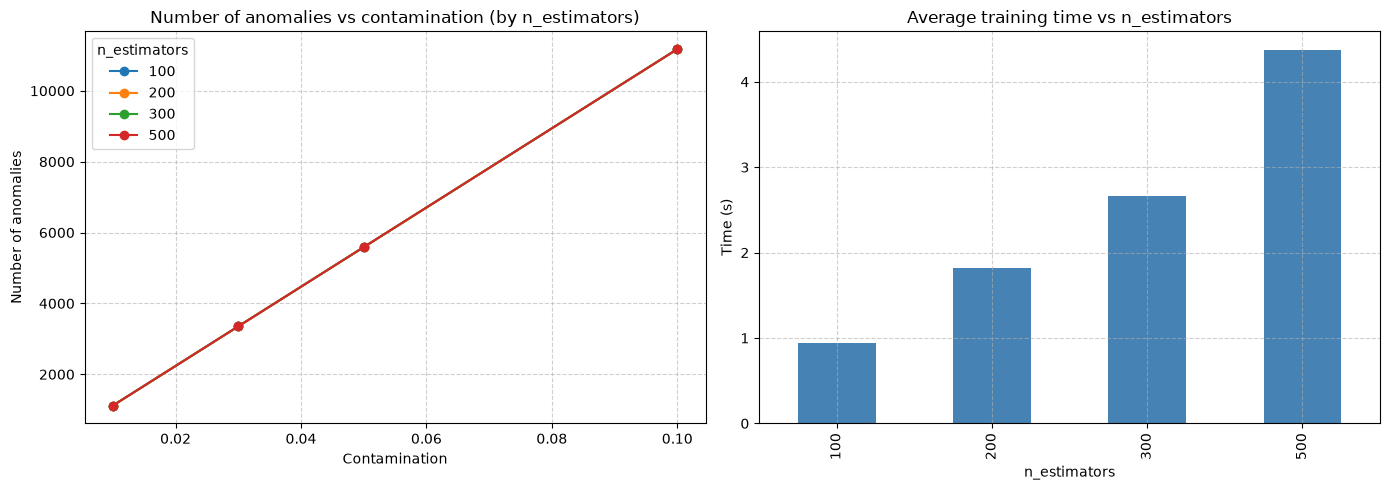

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot = sens_df.pivot(index='contamination', columns='n_estimators', values='n_anomalies')
pivot.plot(marker='o', ax=axes[0])
axes[0].set_title('Number of anomalies vs contamination (by n_estimators)')
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel('Number of anomalies')
axes[0].grid(True, linestyle='--', alpha=0.6)

sens_df.groupby('n_estimators')['fit_time_s'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average training time vs n_estimators')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Time (s)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**Selection rationale:**

- `n_estimators`: the Spearman correlation is already very high between 200 and 300
  trees (≈ 0.99), so **200 would already be enough** for a stable score ranking.
  Keeping 300 is not justified as "the optimal value", but as a **conservative
  trade-off**: a small extra computational cost in exchange for extra stability
  margin, useful for future re-training on slightly different data.
- `contamination`: **0.05 is not a claim that 5% of listings are truly
  anomalous.** It is only the **decision threshold** the model uses to turn the
  continuous score into the binary `if_anomaly` label. It is set to 0.05 by
  convention (typical 1%–5% range in the absence of ground truth), checking that
  the number of anomalies does not vary erratically between nearby grid values
  (see left plot). The continuous score (`if_score`) is what matters for the
  downstream analysis, not the label itself.


In [85]:
IF_PARAMS = {
    'n_estimators': 300,
    'contamination': 0.05,
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}
print("Final Isolation Forest configuration:")
print(json.dumps(IF_PARAMS, indent=2))


Final Isolation Forest configuration:
{
  "n_estimators": 300,
  "contamination": 0.05,
  "random_state": 42,
  "n_jobs": -1
}


## 5. LOF: Baseline

Train a first LOF model on the same `X` matrix used for Isolation Forest.

**Note on dimensionality:** LOF relies on distances/density in the full feature
space of `X`. With `X.shape[1]` ≈ dozens of columns (numeric + one-hot encoded
categoricals), the "curse of dimensionality" makes distances between points tend
to look more similar as dimensionality grows, which can flatten local density
differences and make LOF less discriminative than in low-dimensional settings. No
dimensionality reduction is applied to compensate for this; it is simply flagged here as a known
limitation to keep in mind when reading LOF's local anomalies in Notebook 2.


In [86]:
LOF_PARAMS_BASELINE = {'n_neighbors': 20, 'contamination': 0.05, 'n_jobs': -1}

lof_baseline = LocalOutlierFactor(**LOF_PARAMS_BASELINE)
lof_pred_baseline = lof_baseline.fit_predict(X)
lof_score_baseline = lof_baseline.negative_outlier_factor_ * -1

n_lof_anomalies_baseline = (lof_pred_baseline == -1).sum()
print(f"LOF baseline -> anomalies detected: {n_lof_anomalies_baseline} "
      f"({n_lof_anomalies_baseline / len(X):.2%})")


LOF baseline -> anomalies detected: 5588 (5.00%)


## 6. LOF: Sensitivity Analysis

We mainly study `n_neighbors` (`contamination` fixed at 0.05 to isolate its
effect), looking at the number of anomalies, training time, and the **stability**
of both the anomaly labels (Jaccard similarity) and the continuous scores
(Spearman correlation).


In [87]:
n_neighbors_grid = [10, 20, 30, 50, 100]

lof_sensitivity = []
lof_preds_by_n = {}
for n in n_neighbors_grid:
    t0 = time.time()
    temp_lof = LocalOutlierFactor(n_neighbors=n, contamination=0.05, n_jobs=-1)
    temp_pred = temp_lof.fit_predict(X)
    elapsed = time.time() - t0
    lof_preds_by_n[n] = temp_pred
    lof_sensitivity.append({
        'n_neighbors': n,
        'n_anomalies': int((temp_pred == -1).sum()),
        'fit_time_s': round(elapsed, 2)
    })

lof_sens_df = pd.DataFrame(lof_sensitivity)
display(lof_sens_df)


c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\3. Models\.venv\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,n_neighbors,n_anomalies,fit_time_s
0,10,5588,5.95
1,20,5588,5.96
2,30,5588,6.96
3,50,5588,7.63
4,100,5588,7.94


In [88]:
def jaccard(pred_a, pred_b):
    """Jaccard similarity between two sets of anomaly-flagged (-1) indices."""
    set_a = set(np.where(pred_a == -1)[0])
    set_b = set(np.where(pred_b == -1)[0])
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)

jaccard_matrix = pd.DataFrame(
    [[jaccard(lof_preds_by_n[i], lof_preds_by_n[j]) for j in n_neighbors_grid] for i in n_neighbors_grid],
    index=n_neighbors_grid, columns=n_neighbors_grid
)
print("Jaccard similarity between anomalies detected for each n_neighbors:")
display(jaccard_matrix.round(3))


Jaccard similarity between anomalies detected for each n_neighbors:


,10,20,30,50,100
10,1.000,0.474,0.341,0.246,0.180
20,0.474,1.000,0.645,0.427,0.273
30,0.341,0.645,1.000,0.606,0.358
50,0.246,0.427,0.606,1.000,0.520
100,0.180,0.273,0.358,0.520,1.000


Jaccard only compares **binary labels**, which are sensitive to the cut-off point.
To check whether the anomaly **ranking** is consistent even when some labels
change, we also compare the continuous `lof_score` across configurations via
Spearman correlation.


In [89]:
lof_scores_by_n = {}
for n in n_neighbors_grid:
    temp_lof = LocalOutlierFactor(n_neighbors=n, contamination=0.05, n_jobs=-1)
    temp_lof.fit_predict(X)
    lof_scores_by_n[n] = temp_lof.negative_outlier_factor_ * -1

lof_scores_matrix = pd.DataFrame(lof_scores_by_n)
lof_score_corr = lof_scores_matrix.corr(method='spearman')
print("Spearman correlation between lof_score for different n_neighbors:")
display(lof_score_corr.round(3))


c:\Users\Andres\Documents\University\Máster\Cloud, Datos y Gestión TI\Asignaturas\TFM\Code\3. Models\.venv\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Spearman correlation between lof_score for different n_neighbors:


,10,20,30,50,100
10,1.000,0.769,0.650,0.548,0.462
20,0.769,1.000,0.905,0.756,0.608
30,0.650,0.905,1.000,0.890,0.700
50,0.548,0.756,0.890,1.000,0.839
100,0.462,0.608,0.700,0.839,1.000


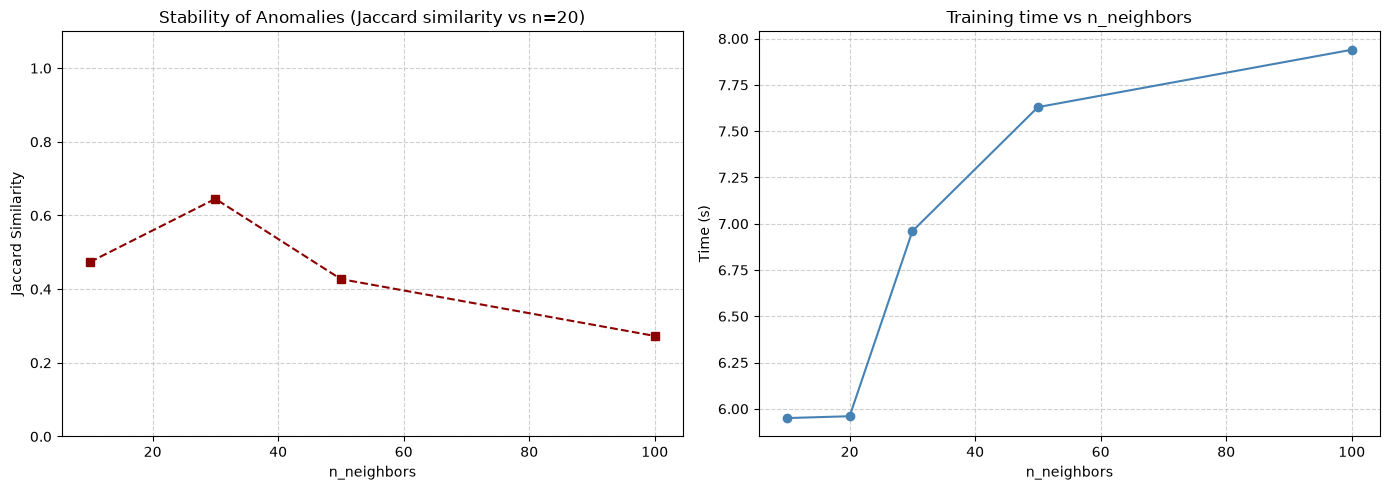

In [90]:
jaccard_vs_20 = jaccard_matrix[20].drop(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(jaccard_vs_20.index, jaccard_vs_20.values, marker='s', color='darkred', linestyle='--')
axes[0].set_title('Stability of Anomalies (Jaccard similarity vs n=20)')
axes[0].set_xlabel('n_neighbors')
axes[0].set_ylabel('Jaccard Similarity')
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(lof_sens_df['n_neighbors'], lof_sens_df['fit_time_s'], marker='o', color='steelblue')
axes[1].set_title('Training time vs n_neighbors')
axes[1].set_xlabel('n_neighbors')
axes[1].set_ylabel('Time (s)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**Selection rationale**:

Unlike n_estimators for Isolation Forest, LOF is sensitive to n_neighbors. The sensitivity analysis reveals that n_neighbors=30 is the optimal trade-off:

- Stability: The Jaccard similarity plot shows that n=30 achieves the highest label consistency, whereas smaller or larger values lead to a rapid decay in stability.

- Efficiency: The training time analysis confirms that n=30 resides in the global minimum of the computational cost curve.

- Model Purpose: This value is large enough to avoid noise sensitivity (inherent in n=10), yet small enough to maintain LOF’s ability to detect local anomalies, providing a necessary counterpoint to Isolation Forest’s global view.

This sensitivity is a known limitation of density-based models. Consequently, n=30 is chosen as a robust, computationally efficient configuration.


In [91]:
LOF_PARAMS = {'n_neighbors': 30, 'contamination': 0.05, 'n_jobs': -1}
print("Final LOF configuration:")
print(json.dumps(LOF_PARAMS, indent=2))


Final LOF configuration:
{
  "n_neighbors": 30,
  "contamination": 0.05,
  "n_jobs": -1
}


## 7. Final model execution

Run both models with their final configuration and generate scores and flags.


In [92]:
if_final = IsolationForest(**IF_PARAMS)

t0 = time.time()
if_final.fit(X)
if_fit_time = time.time() - t0

if_predictions = if_final.predict(X)
if_scores_raw = if_final.decision_function(X)
if_scores = if_scores_raw * -1  # inverted: higher = more anomalous

results_if = ids_df.copy()
results_if['if_score'] = if_scores
results_if['if_anomaly'] = if_predictions

print(f"Final IF training time: {if_fit_time:.2f}s")
print(f"Anomalies detected: {(if_predictions == -1).sum()} ({(if_predictions == -1).mean():.2%})")
display(results_if.sort_values('if_score', ascending=False).head())

Final IF training time: 1.62s
Anomalies detected: 5588 (5.00%)


,id,room_id,name,if_score,if_anomaly
60509,16666796,1666679601,Casa Mil Flores,0.152976,-1
100950,8841824,884182401,Atalya Rio Verde,0.139215,-1
42448,14649912,1464991202,"6 Bedroom Villa Oasis in Ibiza City, 1251",0.131945,-1
80782,5189715,518971501,Finca Avellaneda Casa Completa,0.123709,-1
73041,3385144,338514410,Hotel Rural Don Burguillo,0.122310,-1


In [93]:
lof_final = LocalOutlierFactor(**LOF_PARAMS)
lof_predictions = lof_final.fit_predict(X)
lof_scores = lof_final.negative_outlier_factor_ * -1

model_results = ids_df.copy()
model_results['if_score'] = if_scores
model_results['if_anomaly'] = if_predictions
model_results['lof_score'] = lof_scores
model_results['lof_anomaly'] = lof_predictions

print(f"Results dataframe shape: {model_results.shape}")
display(model_results.head(10))


Results dataframe shape: (111744, 7)


,id,room_id,name,if_score,if_anomaly,lof_score,lof_anomaly
0,10001060,1000106001,Apartamento Ría Villaviciosa,-0.089755,1,1.001846,1
1,10001085,1000108501,Vive tu vida soñada delante del mar,-0.068983,1,1.485054,-1
2,1000112,100011202,La Vista de Medina By La Vista Medina Stays,-0.097054,1,1.094057,1
3,1000115,100011501,Hostal Catalina de Austria,-0.019734,1,1.014811,1
4,1000144,100014401,Casa Candela,-0.035997,1,1.052499,1
5,10001487,1000148703,"Luxury Villa Alma Pool, Garden & Parking",0.018793,-1,1.056060,1
6,10001549,1000154902,Amaya,-0.032718,1,1.057627,1
7,10001677,1000167701,CASA FILA,-0.080000,1,1.038476,1
8,10001710,1000171002,Energías Serenas,0.013651,-1,1.010050,1
9,10001713,1000171301,Apartamento San Gerardo By Solymar Properties,-0.086343,1,1.001567,1


### Final summary table

In [94]:
summary_table = pd.DataFrame([
    {
        'Model': 'Isolation Forest',
        'Anomalies': int((if_predictions == -1).sum()),
        'Percentage': f"{(if_predictions == -1).mean():.2%}",
    },
    {
        'Model': 'LOF',
        'Anomalies': int((lof_predictions == -1).sum()),
        'Percentage': f"{(lof_predictions == -1).mean():.2%}",
    },
])
display(summary_table)


,Model,Anomalies,Percentage
0,Isolation Forest,5588,5.00%
1,LOF,5588,5.00%


## 8. Save outputs

Save the trained models


In [95]:
config_table = pd.DataFrame([
    {'Model': 'Isolation Forest', 'Parameter': 'n_estimators', 'Selected value': IF_PARAMS['n_estimators']},
    {'Model': 'Isolation Forest', 'Parameter': 'contamination', 'Selected value': IF_PARAMS['contamination']},
    {'Model': 'Isolation Forest', 'Parameter': 'random_state', 'Selected value': IF_PARAMS['random_state']},
    {'Model': 'LOF', 'Parameter': 'n_neighbors', 'Selected value': LOF_PARAMS['n_neighbors']},
    {'Model': 'LOF', 'Parameter': 'contamination', 'Selected value': LOF_PARAMS['contamination']},
])
display(config_table)


,Model,Parameter,Selected value
0,Isolation Forest,n_estimators,300.00
1,Isolation Forest,contamination,0.05
2,Isolation Forest,random_state,42.00
3,LOF,n_neighbors,30.00
4,LOF,contamination,0.05


In [96]:
model_results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)

assert len(model_results) == len(X), (
    f"Row count mismatch before concat: model_results has {len(model_results)} rows, "
    f"X has {len(X)} rows."
)
model_results_reset = model_results.reset_index(drop=True)
X_reset = X.reset_index(drop=True)
model_results_full = pd.concat([model_results_reset, X_reset], axis=1)
assert model_results_full.shape[0] == model_results.shape[0], "concat changed the row count unexpectedly."
assert model_results_full.shape[1] == model_results.shape[1] + X.shape[1], "concat changed the column count unexpectedly."

model_results_full.to_csv(OUTPUT_DIR / "model_results_full.csv", index=False)

software_versions = {
    'python': sys.version.split()[0],
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scikit_learn': sklearn.__version__,
}
dataset_info = {
    'file_name': 'dataset_anomaly_detection_ready.csv',
    'n_rows': len(df),
    'n_features': X.shape[1],
    'extraction_id': None,
}

final_config = {
    'software_versions': software_versions,
    'dataset': dataset_info,
    'random_state': RANDOM_STATE,
    'n_observations': len(X),
    'n_features': X.shape[1],
    'feature_columns': feature_cols,
    'isolation_forest': {
        'params': IF_PARAMS,
        'n_anomalies': int((if_predictions == -1).sum()),
        'fit_time_s': round(if_fit_time, 2),
    },
    'local_outlier_factor': {
        'params': LOF_PARAMS,
        'n_anomalies': int((lof_predictions == -1).sum()),
        'fit_time_full_dataset_s': round(lof_full_fit_time, 2),
    },
}
with open(OUTPUT_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(final_config, f, indent=2, ensure_ascii=False)

# Trained models
joblib.dump(if_final, MODELS_DIR / "isolation_forest_final.joblib")

with open(MODELS_DIR / "lof_final_params.json", "w", encoding="utf-8") as f:
    json.dump(LOF_PARAMS, f, indent=2)

print("=" * 60)
print("Models saved")
print("=" * 60)

expected_files = [
    OUTPUT_DIR / 'model_results.csv',
    OUTPUT_DIR / 'model_results_full.csv',
    OUTPUT_DIR / 'model_config.json',
    MODELS_DIR / 'isolation_forest_final.joblib',
    MODELS_DIR / 'lof_final_params.json',
]
for f_path in expected_files:
    print(f"{f_path}")


Models saved
outputs\model_results.csv
outputs\model_results_full.csv
outputs\model_config.json
models\isolation_forest_final.joblib
models\lof_final_params.json
